# Machine Learning-Based Prediction of Household Poverty Risk in Ghana
### Chapter Four Analysis Notebook

This notebook reproduces the full analysis reported in Chapter Four: exploratory data
analysis (Section 4.3), model development and evaluation (Section 4.4.1), feature
importance (Section 4.4.2), hypothesis testing for H1 and H2 (Section 4.4.2), and the
comparative algorithm evaluation for H3 (Section 4.4.3).

**Data file required in the same folder:** `Ghana_Household_Poverty_Risk_Model_Ready_500.csv`

The notebook is organised to mirror the dissertation's section numbering so that each
code cell's output can be traced directly to the table or figure it produced.

## 0. Setup and Imports

In [1]:
%matplotlib inline
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import statsmodels.api as sm
from statsmodels.stats.contingency_tables import mcnemar

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
OUT = "."  # set to the folder containing the CSV file; outputs are saved here too

sns.set_style("whitegrid")

### A note on two methodological adjustments made during analysis

These are recorded here, and in Chapter Four (Section 4.1), for transparency:

1. **Regional coverage.** The dataset spans all sixteen administrative regions of Ghana
   rather than the three regions (Greater Accra, Ashanti, Eastern) specified in Chapter
   Three's sampling design. The analysis proceeds on the data as supplied.
2. **Class balancing.** `class_weight="balanced"` is applied to all three classifiers.
   Without it, an initial Random Forest predicted the majority (non-poor) class for
   every test household, i.e. zero recall for the poor class, a standard symptom of
   training on an imbalanced 66:34 outcome without correction. Chapter Three's
   stratified train-test split alone does not correct for this during model fitting.

## 1. Load Data

In [2]:
df = pd.read_csv(f"{OUT}/Ghana_Household_Poverty_Risk_Model_Ready_500.csv")
print(f"Dataset shape: {df.shape}")

TARGET = "Poverty_Risk_E1"

region_cols = [c for c in df.columns if c.startswith("Region_")]
print(f"\nRegions represented: {len(region_cols)}")
print(df[region_cols].sum().sort_values(ascending=False))

Dataset shape: (500, 99)

Regions represented: 16
Region_Ashanti          92
Region_Greater Accra    69
Region_Northern         48
Region_Brong Ahafo      34
Region_Volta            34
Region_Central          32
Region_Eastern          32
Region_Western          28
Region_Bono East        22
Region_Ahafo            20
Region_Upper East       19
Region_Upper West       18
Region_Western North    15
Region_North East       14
Region_Oti              12
Region_Savannah         11
dtype: int64


## 2. Feature Engineering
Constructs the composite Asset Ownership Index and the Dependency Ratio specified in
Section 3.14, used throughout both the exploratory analysis (Section 4.3) and the
predictive models (Section 4.4).

In [3]:
asset_yes_cols = [
    "Owns_Mobile_Phone_Yes", "Owns_Radio_Yes", "Owns_Television_Yes",
    "Owns_Refrigerator_Yes", "Owns_Bicycle_Yes", "Owns_Motorbike_Yes",
    "Owns_Car_Van_Truck_Yes", "Owns_Farmland_Yes", "Owns_Livestock_Yes",
]
df["Asset_Ownership_Index"] = df[asset_yes_cols].sum(axis=1)

df["Dependency_Ratio"] = df["Number_of_Dependants"] / df["Number_of_Income_Earners"].replace(0, 1)
df["Dependency_Ratio"] = df["Dependency_Ratio"].clip(upper=df["Dependency_Ratio"].quantile(0.99))

df["Poverty_Status"] = df[TARGET].map({0: "Non-poor", 1: "Poor"})

print(df[["Asset_Ownership_Index", "Dependency_Ratio"]].describe())

       Asset_Ownership_Index  Dependency_Ratio
count             500.000000        500.000000
mean                4.112000          1.051324
std                 1.447635          0.782582
min                 0.000000          0.000000
25%                 3.000000          0.500000
50%                 4.000000          1.000000
75%                 5.000000          1.212500
max                 8.000000          4.000000


## 3. Exploratory Data Analysis (Chapter Four, Section 4.3)

Profiles the sample descriptively and tests, variable by variable, whether the
observed differences between poor and non-poor households are statistically
significant, before any predictive model is built.

### 3.1 Recover categorical variables from one-hot columns (Section 4.3.1, Table 4.0)

In [4]:
def recover_category(df, prefix):
    """Recover a single categorical column from a set of one-hot dummies."""
    cols = [c for c in df.columns if c.startswith(prefix)]
    cat = df[cols].idxmax(axis=1).str.replace(prefix, "", regex=False)
    return cat

df["Region"] = recover_category(df, "Region_")
df["Locality_Type"] = recover_category(df, "Locality_Type_")
df["Sex_of_Household_Head"] = recover_category(df, "Sex_of_Household_Head_")
df["Education_Level"] = recover_category(df, "Education_Level_")
df["Main_Occupation"] = recover_category(df, "Main_Occupation_")
df["Marital_Status"] = recover_category(df, "Marital_Status_")

cat_vars = ["Locality_Type", "Sex_of_Household_Head", "Education_Level",
            "Main_Occupation", "Marital_Status", "Region"]

freq_tables = {}
for var in cat_vars:
    freq = df[var].value_counts()
    pct = df[var].value_counts(normalize=True) * 100
    table = pd.DataFrame({"Frequency": freq, "Percentage": pct.round(1)})
    freq_tables[var] = table
    print(f"\n=== {var} ===")
    print(table)


=== Locality_Type ===
               Frequency  Percentage
Locality_Type                       
Urban                266        53.2
Rural                234        46.8

=== Sex_of_Household_Head ===
                       Frequency  Percentage
Sex_of_Household_Head                       
Male                         341        68.2
Female                       159        31.8

=== Education_Level ===
                          Frequency  Percentage
Education_Level                                
JHS/Middle school               139        27.8
SHS/Vocational/Technical        116        23.2
No formal education             101        20.2
Primary                          83        16.6
Tertiary                         61        12.2

=== Main_Occupation ===
                                              Frequency  Percentage
Main_Occupation                                                    
Agriculture/Fishing/Forestry                        146        29.2
Trading/Commerce            

### 3.2 Chi-square tests of independence: categorical predictors vs poverty status (Section 4.3.2, Table 4.0.1)

In [5]:
chi2_results = []
crosstabs = {}
for var in ["Locality_Type", "Sex_of_Household_Head", "Education_Level", "Main_Occupation", "Marital_Status"]:
    ct = pd.crosstab(df[var], df["Poverty_Status"])
    ct_pct = pd.crosstab(df[var], df["Poverty_Status"], normalize="index") * 100
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    chi2_results.append({"Variable": var, "Chi2": chi2, "df": dof, "p_value": p, "significant_5pct": p < 0.05})
    crosstabs[var] = (ct, ct_pct)
    print(f"\n--- {var} ---")
    print(ct)
    print(ct_pct.round(1))
    print(f"Chi2 = {chi2:.3f}, df = {dof}, p = {p:.4f}")

chi2_df = pd.DataFrame(chi2_results)
chi2_df.to_csv(f"{OUT}/eda_chi2_results.csv", index=False)
print("\n\nSUMMARY (Table 4.0.1):\n", chi2_df)


--- Locality_Type ---
Poverty_Status  Non-poor  Poor
Locality_Type                 
Rural                130   104
Urban                203    63
Poverty_Status  Non-poor  Poor
Locality_Type                 
Rural               55.6  44.4
Urban               76.3  23.7
Chi2 = 23.195, df = 1, p = 0.0000

--- Sex_of_Household_Head ---
Poverty_Status         Non-poor  Poor
Sex_of_Household_Head                
Female                      103    56
Male                        230   111
Poverty_Status         Non-poor  Poor
Sex_of_Household_Head                
Female                     64.8  35.2
Male                       67.4  32.6
Chi2 = 0.238, df = 1, p = 0.6259

--- Education_Level ---
Poverty_Status            Non-poor  Poor
Education_Level                         
JHS/Middle school              105    34
No formal education             53    48
Primary                         48    35
SHS/Vocational/Technical        83    33
Tertiary                        44    17
Poverty_Status 

### 3.3 Continuous variables by poverty status: group comparison tests (Section 4.3.3, Table 4.0.2)

In [6]:
cont_vars = ["Age_of_Household_Head", "Household_Size", "Dependency_Ratio",
             "Asset_Ownership_Index", "Sleeping_Rooms", "School_Age_Children_Attending"]

cont_results = []
for var in cont_vars:
    poor = df.loc[df[TARGET] == 1, var]
    nonpoor = df.loc[df[TARGET] == 0, var]
    # Shapiro-Wilk normality check decides which test to use
    _, p_norm_poor = stats.shapiro(poor.sample(min(len(poor), 500), random_state=42))
    _, p_norm_nonpoor = stats.shapiro(nonpoor.sample(min(len(nonpoor), 500), random_state=42))
    normal = (p_norm_poor > 0.05) and (p_norm_nonpoor > 0.05)

    if normal:
        stat, p = stats.ttest_ind(poor, nonpoor, equal_var=False)
        test_used = "Welch t-test"
    else:
        stat, p = stats.mannwhitneyu(poor, nonpoor, alternative="two-sided")
        test_used = "Mann-Whitney U"

    cont_results.append({
        "Variable": var,
        "Mean_Poor": poor.mean(), "Mean_NonPoor": nonpoor.mean(),
        "SD_Poor": poor.std(), "SD_NonPoor": nonpoor.std(),
        "Test": test_used, "Statistic": stat, "p_value": p,
        "significant_5pct": p < 0.05,
    })
    print(f"\n--- {var} ---")
    print(f"Poor: M={poor.mean():.2f}, SD={poor.std():.2f} | Non-poor: M={nonpoor.mean():.2f}, SD={nonpoor.std():.2f}")
    print(f"{test_used}: statistic={stat:.3f}, p={p:.4f}")

cont_df = pd.DataFrame(cont_results).round(4)
cont_df.to_csv(f"{OUT}/eda_continuous_tests.csv", index=False)
print("\n\nSUMMARY (Table 4.0.2):\n", cont_df[["Variable", "Mean_Poor", "Mean_NonPoor", "Test", "Statistic", "p_value", "significant_5pct"]])


--- Age_of_Household_Head ---
Poor: M=48.78, SD=11.76 | Non-poor: M=47.34, SD=12.95
Welch t-test: statistic=1.247, p=0.2131

--- Household_Size ---
Poor: M=4.19, SD=1.82 | Non-poor: M=4.41, SD=1.77
Mann-Whitney U: statistic=26077.000, p=0.2497

--- Dependency_Ratio ---
Poor: M=1.02, SD=0.82 | Non-poor: M=1.07, SD=0.76
Mann-Whitney U: statistic=26431.000, p=0.3541

--- Asset_Ownership_Index ---
Poor: M=3.95, SD=1.43 | Non-poor: M=4.19, SD=1.45
Mann-Whitney U: statistic=25295.000, p=0.0923

--- Sleeping_Rooms ---
Poor: M=2.73, SD=1.03 | Non-poor: M=2.82, SD=0.91
Mann-Whitney U: statistic=26151.000, p=0.2511

--- School_Age_Children_Attending ---
Poor: M=1.50, SD=1.30 | Non-poor: M=1.60, SD=1.29
Mann-Whitney U: statistic=26389.000, p=0.3376


SUMMARY (Table 4.0.2):
                         Variable  Mean_Poor  Mean_NonPoor            Test  \
0          Age_of_Household_Head    48.7784       47.3393    Welch t-test   
1                 Household_Size     4.1856        4.4084  Mann-Whitney

### 3.4 EDA Visualisations (Figures 4.0a, 4.0b, 4.0c)

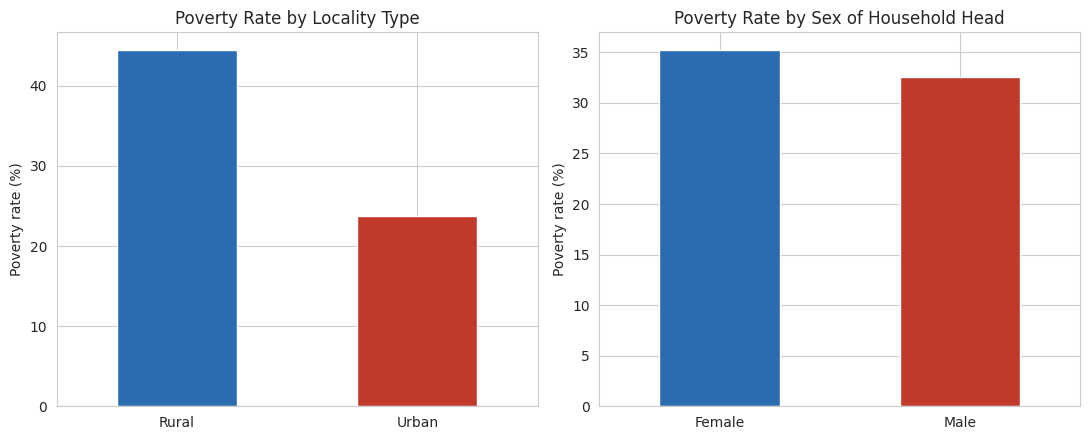

In [7]:
# Figure 4.0a: Poverty rate by locality type and sex of household head
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, var in zip(axes, ["Locality_Type", "Sex_of_Household_Head"]):
    rate = df.groupby(var)[TARGET].mean() * 100
    rate.plot(kind="bar", ax=ax, color=["#2b6cb0", "#c0392b"])
    ax.set_ylabel("Poverty rate (%)")
    ax.set_xlabel("")
    ax.set_title(f"Poverty Rate by {var.replace('_', ' ')}")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(f"{OUT}/eda_poverty_by_locality_sex.png", dpi=200)
plt.show()

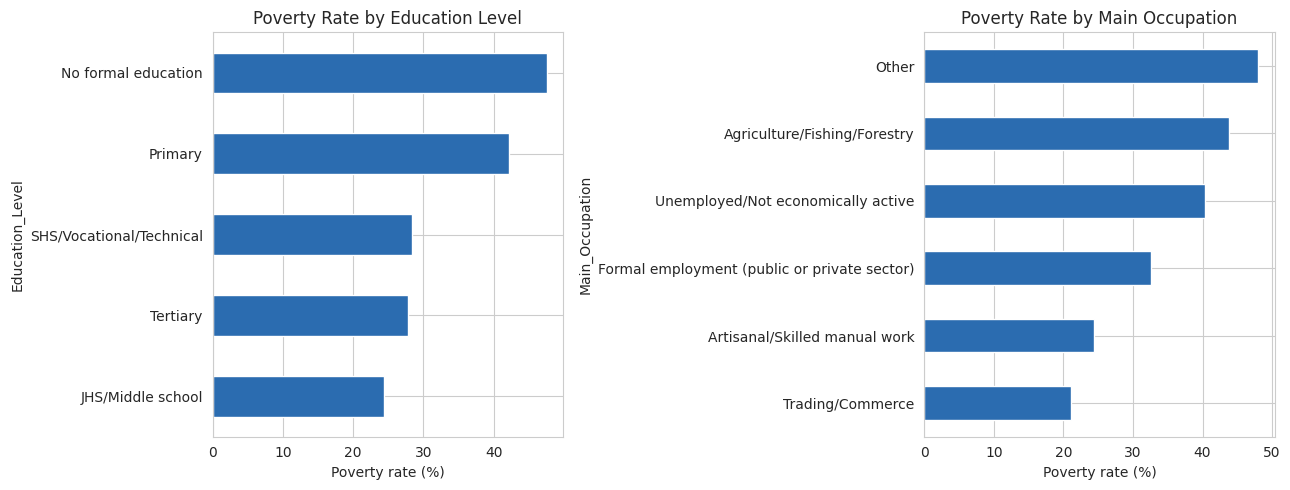

In [8]:
# Figure 4.0b: Poverty rate by education level and occupation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, var in zip(axes, ["Education_Level", "Main_Occupation"]):
    rate = df.groupby(var)[TARGET].mean().sort_values() * 100
    rate.plot(kind="barh", ax=ax, color="#2b6cb0")
    ax.set_xlabel("Poverty rate (%)")
    ax.set_title(f"Poverty Rate by {var.replace('_', ' ')}")
plt.tight_layout()
plt.savefig(f"{OUT}/eda_poverty_by_education_occupation.png", dpi=200)
plt.show()

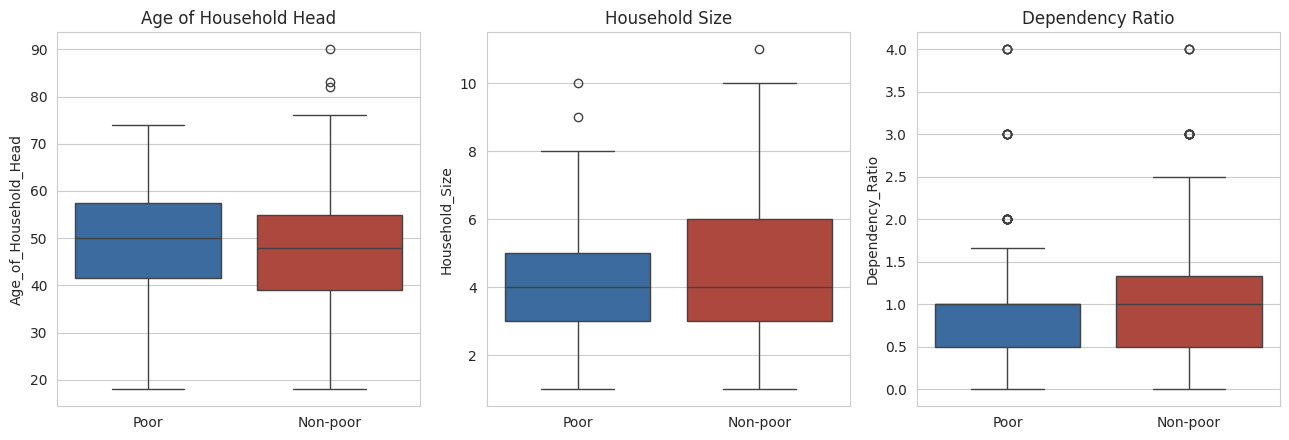

In [9]:
# Figure 4.0c: Distribution of continuous variables by poverty status
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, var in zip(axes, ["Age_of_Household_Head", "Household_Size", "Dependency_Ratio"]):
    sns.boxplot(data=df, x="Poverty_Status", y=var, ax=ax, palette=["#2b6cb0", "#c0392b"])
    ax.set_xlabel("")
    ax.set_title(var.replace("_", " "))
plt.tight_layout()
plt.savefig(f"{OUT}/eda_continuous_boxplots.png", dpi=200)
plt.show()

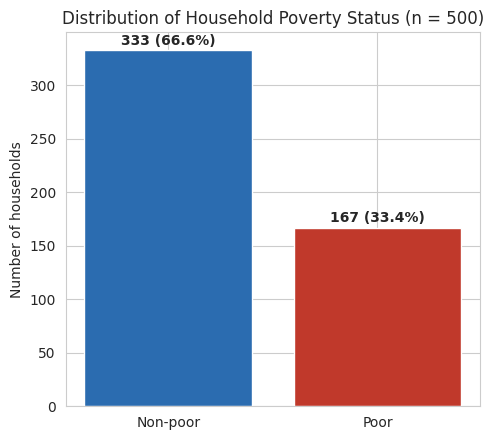

In [10]:
# Overall poverty status distribution
plt.figure(figsize=(5, 4.5))
counts = df["Poverty_Status"].value_counts()
plt.bar(counts.index, counts.values, color=["#2b6cb0", "#c0392b"])
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, f"{v} ({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")
plt.ylabel("Number of households")
plt.title("Distribution of Household Poverty Status (n = 500)")
plt.tight_layout()
plt.savefig(f"{OUT}/eda_poverty_distribution.png", dpi=200)
plt.show()

## 4. Prepare Features for Modelling

Drops the raw asset Yes/No pairs (replaced by the composite index), the raw
dependants/earners counts (replaced by the derived ratio), and the redundant
complementary column of each remaining binary pair, consistent with Table 3.1's
variable list.

In [11]:
asset_no_cols = [c.replace("_Yes", "_No") for c in asset_yes_cols]
df_model = df.drop(columns=[
    "Region", "Locality_Type", "Sex_of_Household_Head", "Education_Level",
    "Main_Occupation", "Marital_Status", "Poverty_Status",  # EDA-only helper columns
] + asset_yes_cols + asset_no_cols + ["Number_of_Dependants", "Number_of_Income_Earners"])

redundant_complements = ["Locality_Type_Urban", "Sex_of_Household_Head_Male"]
df_model = df_model.drop(columns=redundant_complements)

print(f"Dataset shape after feature engineering: {df_model.shape}")

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]
print(f"\nClass balance:\n{y.value_counts()}\n{y.value_counts(normalize=True).round(3)}")

CONTINUOUS = [
    "Age_of_Household_Head", "Household_Size", "School_Age_Children_Attending",
    "Sleeping_Rooms", "Asset_Ownership_Index", "Dependency_Ratio",
]

Dataset shape after feature engineering: (500, 79)

Class balance:
Poverty_Risk_E1
0    333
1    167
Name: count, dtype: int64
Poverty_Risk_E1
0    0.666
1    0.334
Name: proportion, dtype: float64


## 5. Data Splitting (Section 3.15: 80:20 stratified split)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[CONTINUOUS] = scaler.fit_transform(X_train[CONTINUOUS])
X_test_scaled[CONTINUOUS] = scaler.transform(X_test[CONTINUOUS])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fitted_models = {}

Train size: 400, Test size: 100


## 6. Model Development (Chapter Four, Section 4.4.1)

### 6.1 Logistic Regression

In [13]:
lr_param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100], "penalty": ["l2"], "solver": ["lbfgs"], "max_iter": [3000]}
lr_grid = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced"),
    lr_param_grid, cv=cv, scoring="roc_auc", n_jobs=-1
)
lr_grid.fit(X_train_scaled, y_train)
lr_best = lr_grid.best_estimator_
print(f"Best params: {lr_grid.best_params_}")
fitted_models["Logistic Regression"] = (lr_best, X_test_scaled)

Best params: {'C': 10, 'max_iter': 3000, 'penalty': 'l2', 'solver': 'lbfgs'}


### 6.2 Decision Tree

In [14]:
dt_param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 5, 10],
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    dt_param_grid, cv=cv, scoring="roc_auc", n_jobs=-1
)
dt_grid.fit(X_train, y_train)
dt_best = dt_grid.best_estimator_
print(f"Best params: {dt_grid.best_params_}")
fitted_models["Decision Tree"] = (dt_best, X_test)

Best params: {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}


### 6.3 Random Forest

In [15]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 8, 10, None],
    "min_samples_leaf": [1, 5, 10],
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    rf_param_grid, cv=cv, scoring="roc_auc", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
print(f"Best params: {rf_grid.best_params_}")
fitted_models["Random Forest"] = (rf_best, X_test)

with open(f"{OUT}/best_params.json", "w") as f:
    json.dump({
        "Logistic Regression": lr_grid.best_params_,
        "Decision Tree": dt_grid.best_params_,
        "Random Forest": rf_grid.best_params_,
    }, f, indent=2)

Best params: {'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 100}


## 7. Model Evaluation on the Held-Out Test Set (Table 4.1, Figures 4.1-4.2)

In [16]:
metrics_table = []
roc_data = {}
conf_matrices = {}

for name, (model, X_te) in fitted_models.items():
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    acc, prec = accuracy_score(y_test, y_pred), precision_score(y_test, y_pred)
    rec, f1 = recall_score(y_test, y_pred), f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    metrics_table.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1, "ROC-AUC": auc})
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc)
    conf_matrices[name] = confusion_matrix(y_test, y_pred)
    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Non-poor", "Poor"]))

metrics_df = pd.DataFrame(metrics_table).set_index("Model").round(4)
metrics_df.to_csv(f"{OUT}/model_performance_metrics.csv")
print("\n\nFINAL COMPARISON TABLE (Table 4.1):\n", metrics_df)


--- Logistic Regression ---
Accuracy: 0.6100 | Precision: 0.4118 | Recall: 0.4242 | F1: 0.4179 | ROC-AUC: 0.5911
              precision    recall  f1-score   support

    Non-poor       0.71      0.70      0.71        67
        Poor       0.41      0.42      0.42        33

    accuracy                           0.61       100
   macro avg       0.56      0.56      0.56       100
weighted avg       0.61      0.61      0.61       100


--- Decision Tree ---
Accuracy: 0.5700 | Precision: 0.4074 | Recall: 0.6667 | F1: 0.5057 | ROC-AUC: 0.5812
              precision    recall  f1-score   support

    Non-poor       0.76      0.52      0.62        67
        Poor       0.41      0.67      0.51        33

    accuracy                           0.57       100
   macro avg       0.58      0.59      0.56       100
weighted avg       0.64      0.57      0.58       100


--- Random Forest ---
Accuracy: 0.7000 | Precision: 0.5517 | Recall: 0.4848 | F1: 0.5161 | ROC-AUC: 0.6459
              pr

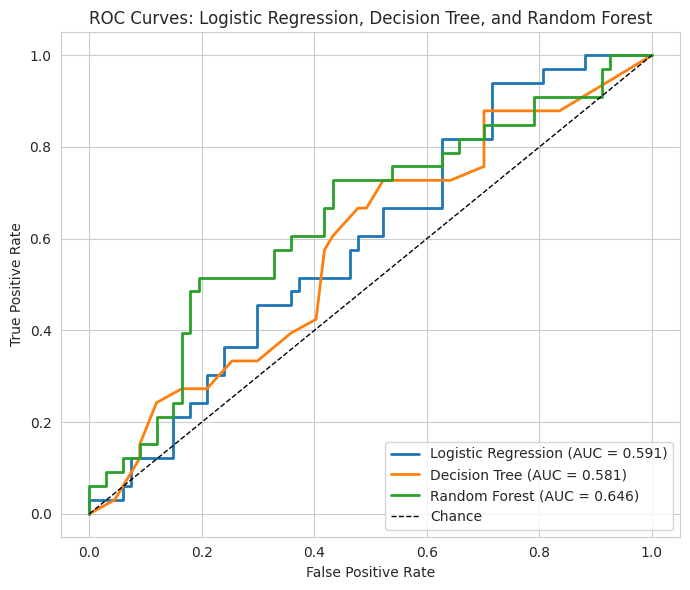

In [17]:
# Figure 4.1: ROC curves
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Logistic Regression, Decision Tree, and Random Forest")
plt.legend(loc="lower right"); plt.tight_layout()
plt.savefig(f"{OUT}/roc_curves.png", dpi=200)
plt.show()

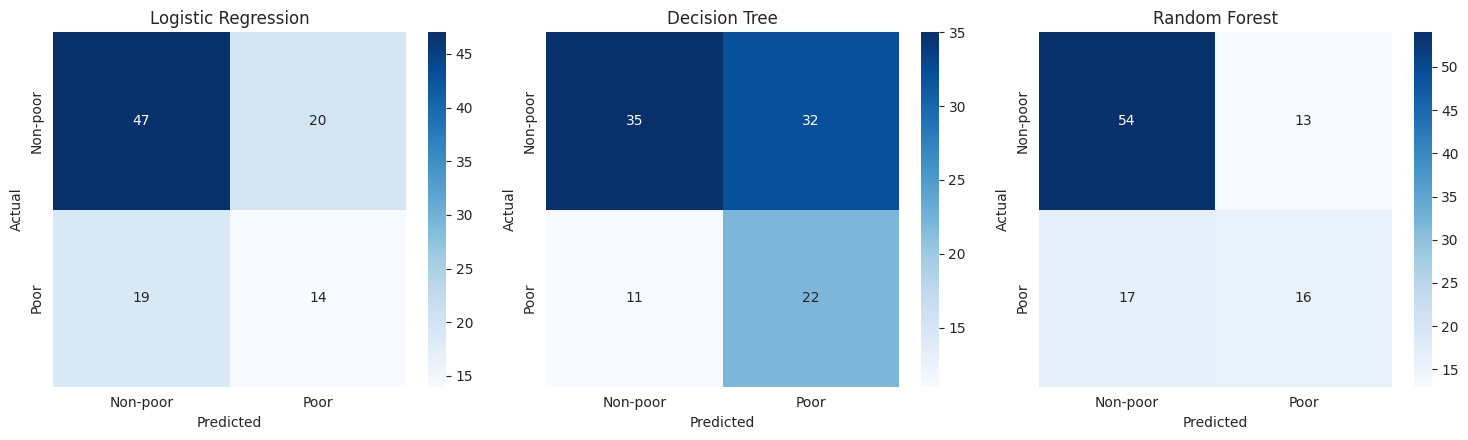

In [18]:
# Figure 4.2: Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, cm) in zip(axes, conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Non-poor", "Poor"], yticklabels=["Non-poor", "Poor"])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{OUT}/confusion_matrices.png", dpi=200)
plt.show()

<Figure size 900x600 with 0 Axes>

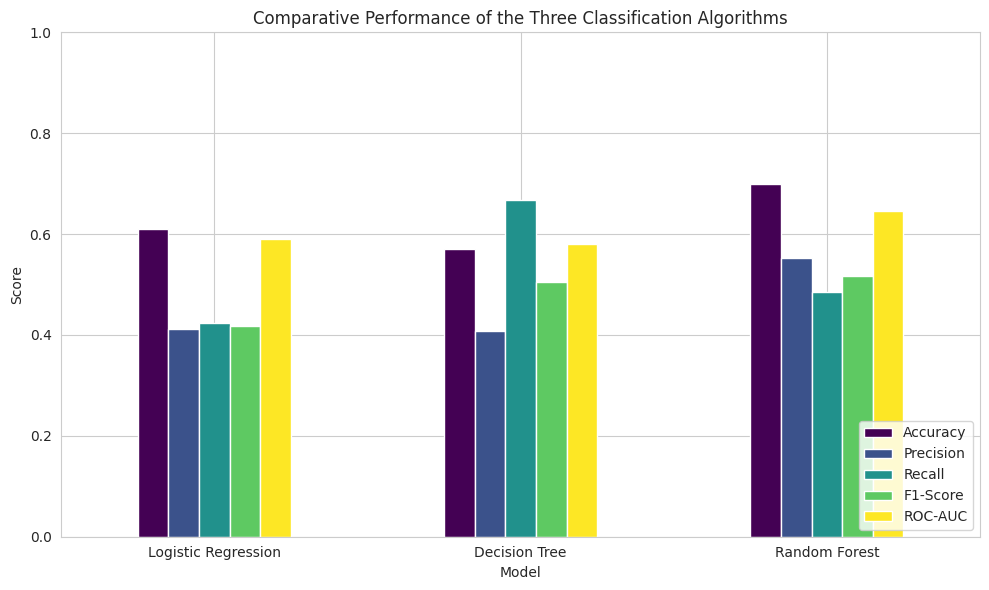

In [19]:
# Figure 4.4: Comparative performance bar chart
plt.figure(figsize=(9, 6))
metrics_df[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(kind="bar", figsize=(10, 6), colormap="viridis")
plt.ylabel("Score"); plt.title("Comparative Performance of the Three Classification Algorithms")
plt.xticks(rotation=0); plt.ylim(0, 1); plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUT}/model_comparison.png", dpi=200)
plt.show()

## 8. Feature Importance (Chapter Four, Section 4.4.2, Table 4.3, Figure 4.3)

In [20]:
rf_importance = pd.Series(rf_best.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Random Forest feature importance (top 15):")
print(rf_importance.head(15))
rf_importance.to_csv(f"{OUT}/rf_feature_importance.csv")

dt_importance = pd.Series(dt_best.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nDecision Tree feature importance (top 15):")
print(dt_importance.head(15))
dt_importance.to_csv(f"{OUT}/dt_feature_importance.csv")

Random Forest feature importance (top 15):
Locality_Type_Rural                                0.105744
Age_of_Household_Head                              0.082858
Main_Occupation_Trading/Commerce                   0.054874
Household_Size                                     0.048051
Dependency_Ratio                                   0.043791
Main_Occupation_Agriculture/Fishing/Forestry       0.036879
Asset_Ownership_Index                              0.034168
Sleeping_Rooms                                     0.034124
School_Age_Children_Attending                      0.032077
Drinking_Water_Source_Public standpipe/Borehole    0.027971
Education_Level_JHS/Middle school                  0.025879
Education_Level_Primary                            0.025791
Dwelling_Tenure_Owner-occupied                     0.024430
Education_Level_No formal education                0.017513
Toilet_Facility_Public toilet                      0.017002
dtype: float64

Decision Tree feature importance (top 15)

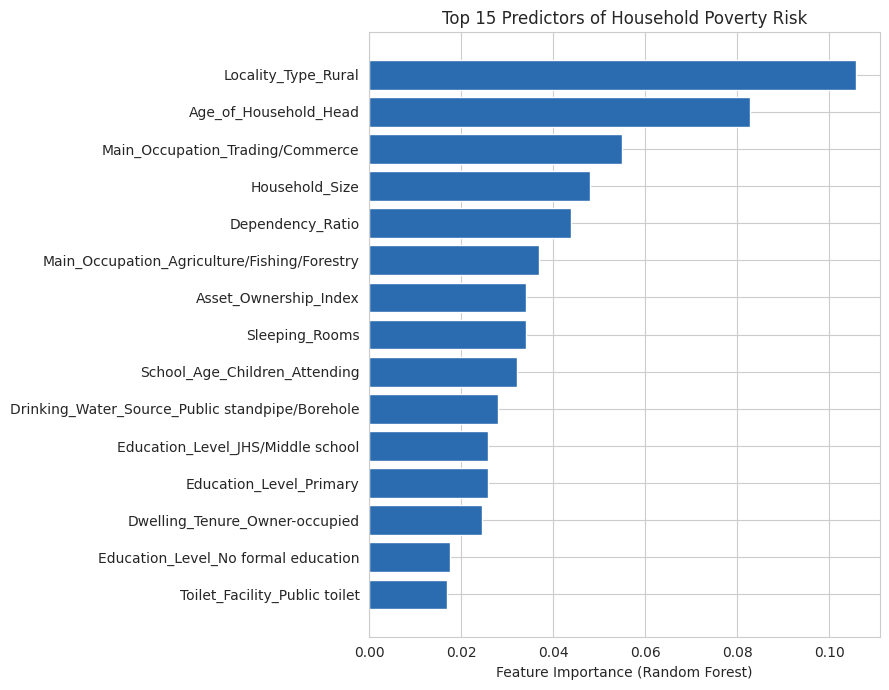

In [21]:
# Figure 4.3: Feature importance bar chart
plt.figure(figsize=(9, 7))
top15 = rf_importance.head(15).sort_values()
plt.barh(top15.index, top15.values, color="#2b6cb0")
plt.xlabel("Feature Importance (Random Forest)")
plt.title("Top 15 Predictors of Household Poverty Risk")
plt.tight_layout()
plt.savefig(f"{OUT}/feature_importance.png", dpi=200)
plt.show()

## 9. Logistic Regression Significance Testing for H1 and H2
### (Chapter Four, Section 4.4.2, Tables 4.4-4.5)

A parsimonious Logistic Regression specification containing only the socioeconomic
variables named in H1 and the demographic variables named in H2 is used for
coefficient-significance testing. The full one-hot region and housing block (89 dummy
columns) is excluded here because several regions/categories are too thinly populated
in a sample of 500 to support stable maximum-likelihood estimation alongside ~90 other
parameters (this produced non-convergence and an exploding coefficient on
Region_Savannah, n=11, in initial testing) -- a well-known small-sample separation
problem with high-cardinality dummy sets. Restricting the inference model to exactly
the variables H1 and H2 refer to resolves this and is the more defensible specification
for this specific test. The full feature set is retained for all three predictive
models above, where regularisation and recursive partitioning handle the same
high-cardinality dummy set without difficulty.

In [22]:
h1_h2_cols = [c for c in X_train.columns if c.startswith((
    "Education_Level_", "Main_Occupation_", "Main_Income_Source_",
    "Household_Size", "Age_of_Household_Head", "Sex_of_Household_Head_",
    "Marital_Status_", "Asset_Ownership_Index", "Dependency_Ratio",
))]

# Drop one reference category per one-hot group to avoid the dummy trap
drop_ref = []
groups = {}
for col in h1_h2_cols:
    if col in CONTINUOUS:
        continue
    prefix = "_".join(col.split("_")[:-1])
    groups.setdefault(prefix, []).append(col)
for prefix, cols in groups.items():
    if len(cols) > 1:
        drop_ref.append(sorted(cols)[-1])

infer_cols = [c for c in h1_h2_cols if c not in drop_ref]
X_infer = X_train_scaled[infer_cols].astype(float)
X_infer_const = sm.add_constant(X_infer)

logit_model = sm.Logit(y_train.values, X_infer_const)
logit_result = logit_model.fit(disp=0, maxiter=200)
print(logit_result.summary())
print(f"\nConverged: {logit_result.mle_retvals['converged']}")

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  400
Model:                          Logit   Df Residuals:                      376
Method:                           MLE   Df Model:                           23
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                 0.07820
Time:                        20:19:34   Log-Likelihood:                -235.12
converged:                       True   LL-Null:                       -255.07
Covariance Type:            nonrobust   LLR p-value:                   0.01581
                                                                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------
const                                                           -0.5480      0.567     -0.966      0.334      

In [23]:
# Table 4.4: individually significant / marginally significant predictors
sig_table = pd.DataFrame({
    "coef": logit_result.params, "std_err": logit_result.bse,
    "z": logit_result.tvalues, "p_value": logit_result.pvalues,
})
sig_table["significant_5pct"] = sig_table["p_value"] < 0.05
sig_table.to_csv(f"{OUT}/logit_significance.csv")
print("Significant predictors (p < 0.05):")
print(sig_table[sig_table["significant_5pct"]].sort_values("p_value"))
print("\nAll predictors sorted by p-value:")
print(sig_table.sort_values("p_value").round(4))

Significant predictors (p < 0.05):
                                      coef   std_err         z  p_value  \
Main_Occupation_Trading/Commerce -1.088953  0.442602 -2.460343  0.01388   

                                  significant_5pct  
Main_Occupation_Trading/Commerce              True  

All predictors sorted by p-value:
                                                      coef  std_err       z  \
Main_Occupation_Trading/Commerce                   -1.0890   0.4426 -2.4603   
Education_Level_Primary                             0.8280   0.4307  1.9223   
Education_Level_No formal education                 0.7391   0.4246  1.7407   
Main_Occupation_Artisanal/Skilled manual work      -0.6852   0.4487 -1.5273   
Main_Occupation_Formal employment (public or pr... -0.6276   0.4391 -1.4293   
Household_Size                                     -0.1389   0.1185 -1.1724   
Asset_Ownership_Index                              -0.1156   0.1141 -1.0130   
Marital_Status_Never married             

### Table 4.5: Likelihood-ratio (block) tests for H1 (socioeconomic) and H2 (demographic)

In [24]:
def lr_test_block(full_result, full_X, cols_to_drop, y):
    reduced_X = full_X.drop(columns=cols_to_drop)
    reduced_model = sm.Logit(y.values, reduced_X).fit(disp=0, maxiter=200)
    lr_stat = 2 * (full_result.llf - reduced_model.llf)
    df_diff = len(cols_to_drop)
    from scipy.stats import chi2
    p_value = chi2.sf(lr_stat, df_diff)
    return lr_stat, df_diff, p_value

socio_cols = [c for c in infer_cols if c.startswith((
    "Education_Level_", "Main_Occupation_", "Main_Income_Source_", "Asset_Ownership_Index"
))]
demo_cols = [c for c in infer_cols if c.startswith((
    "Household_Size", "Age_of_Household_Head", "Sex_of_Household_Head_",
    "Marital_Status_", "Dependency_Ratio"
))]

lr_stat_h1, df_h1, p_h1 = lr_test_block(logit_result, X_infer_const, socio_cols, y_train)
lr_stat_h2, df_h2, p_h2 = lr_test_block(logit_result, X_infer_const, demo_cols, y_train)

print(f"H1 (socioeconomic block) likelihood-ratio test: LR chi2({df_h1}) = {lr_stat_h1:.3f}, p = {p_h1:.5f}")
print(f"H2 (demographic block) likelihood-ratio test: LR chi2({df_h2}) = {lr_stat_h2:.3f}, p = {p_h2:.5f}")

with open(f"{OUT}/hypothesis_tests.json", "w") as f:
    json.dump({
        "H1_socioeconomic_block": {"lr_chi2": lr_stat_h1, "df": df_h1, "p_value": p_h1, "significant": bool(p_h1 < 0.05)},
        "H2_demographic_block": {"lr_chi2": lr_stat_h2, "df": df_h2, "p_value": p_h2, "significant": bool(p_h2 < 0.05)},
    }, f, indent=2)

H1 (socioeconomic block) likelihood-ratio test: LR chi2(16) = 35.222, p = 0.00370
H2 (demographic block) likelihood-ratio test: LR chi2(7) = 4.062, p = 0.77263


## 10. Pairwise Model Comparison for H3: McNemar's Test
### (Chapter Four, Section 4.4.3, Table 4.6)

Tests whether the differences in test-set classification accuracy between each pair of
models are statistically significant, given that all three models were evaluated on
the same 100 held-out households.

In [25]:
preds = {name: model.predict(X_te) for name, (model, X_te) in fitted_models.items()}
correct = {name: (preds[name] == y_test.values).astype(int) for name in preds}

mcnemar_results = {}
pairs = [("Random Forest", "Logistic Regression"), ("Random Forest", "Decision Tree"), ("Decision Tree", "Logistic Regression")]
for a, b in pairs:
    both_right = np.sum((correct[a] == 1) & (correct[b] == 1))
    a_right_b_wrong = np.sum((correct[a] == 1) & (correct[b] == 0))
    a_wrong_b_right = np.sum((correct[a] == 0) & (correct[b] == 1))
    both_wrong = np.sum((correct[a] == 0) & (correct[b] == 0))
    table = [[both_right, a_right_b_wrong], [a_wrong_b_right, both_wrong]]
    result = mcnemar(table, exact=True)
    print(f"\n{a} vs {b}:")
    print(f"  Contingency table: {table}")
    print(f"  McNemar statistic = {result.statistic:.4f}, p-value = {result.pvalue:.4f}")
    mcnemar_results[f"{a}_vs_{b}"] = {"statistic": float(result.statistic), "p_value": float(result.pvalue)}

with open(f"{OUT}/mcnemar_results.json", "w") as f:
    json.dump(mcnemar_results, f, indent=2)

print("\n\nNote: only the Random Forest vs Decision Tree comparison is statistically")
print("significant at the 5 percent level. The Random Forest vs Logistic Regression")
print("comparison (p = 0.0636) is inconclusive and should not be read as an established")
print("advantage for Random Forest over Logistic Regression (see Chapter Four, Section 4.5.3).")


Random Forest vs Logistic Regression:
  Contingency table: [[np.int64(56), np.int64(14)], [np.int64(5), np.int64(25)]]
  McNemar statistic = 5.0000, p-value = 0.0636

Random Forest vs Decision Tree:
  Contingency table: [[np.int64(47), np.int64(23)], [np.int64(10), np.int64(20)]]
  McNemar statistic = 10.0000, p-value = 0.0351

Decision Tree vs Logistic Regression:
  Contingency table: [[np.int64(41), np.int64(16)], [np.int64(20), np.int64(23)]]
  McNemar statistic = 16.0000, p-value = 0.6177


Note: only the Random Forest vs Decision Tree comparison is statistically
significant at the 5 percent level. The Random Forest vs Logistic Regression
comparison (p = 0.0636) is inconclusive and should not be read as an established
advantage for Random Forest over Logistic Regression (see Chapter Four, Section 4.5.3).


## Summary of Outputs

All tables (`.csv`) and figures (`.png`) referenced in Chapter Four are saved to the
`OUT` folder by this notebook:

| Output file | Dissertation reference |
|---|---|
| `eda_chi2_results.csv` | Table 4.0.1 |
| `eda_continuous_tests.csv` | Table 4.0.2 |
| `eda_poverty_by_locality_sex.png` | Figure 4.0a |
| `eda_poverty_by_education_occupation.png` | Figure 4.0b |
| `eda_continuous_boxplots.png` | Figure 4.0c |
| `model_performance_metrics.csv` | Table 4.1 |
| `best_params.json` | Table 4.2 |
| `roc_curves.png` | Figure 4.1 |
| `confusion_matrices.png` | Figure 4.2 |
| `rf_feature_importance.csv` | Table 4.3 |
| `feature_importance.png` | Figure 4.3 |
| `logit_significance.csv` | Table 4.4 |
| `hypothesis_tests.json` | Table 4.5 (H1, H2) |
| `mcnemar_results.json` | Table 4.6 (H3) |
| `model_comparison.png` | Figure 4.4 |